In [32]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

In [54]:
data = pd.read_csv('data/problem_data.csv', header=0, sep=';')
n = len(data['avg_sleep_hours'])
data.head()

,student_id,avg_sleep_hours
0,1,5.8
1,2,6.2
2,3,6.5
3,4,5.9
4,5,6.8


In [60]:
mu_0 = 7.5
sigma_0 = 1.2
sigma = 1.5

var_0 = sigma_0**2
var = sigma**2

In [61]:
mu_sample = np.mean(data['avg_sleep_hours'])

posterior_var = 1 / (n/var + 1/var_0)
posterior_mu = posterior_var * (mu_sample * n/var + mu_0/var_0)
posterior_sigma = np.sqrt(posterior_var)

x = np.linspace(min(data['avg_sleep_hours'])-2, max(data['avg_sleep_hours'])+2, 500)
prior_pdf = (1 / (sigma_0 * np.sqrt(2*np.pi))) * np.exp(-(x - mu_0)**2 / (2*sigma_0**2))
posterior_pdf = (1 / (posterior_sigma * np.sqrt(2*np.pi))) * np.exp(-(x - posterior_mu)**2 / (2*posterior_sigma**2))

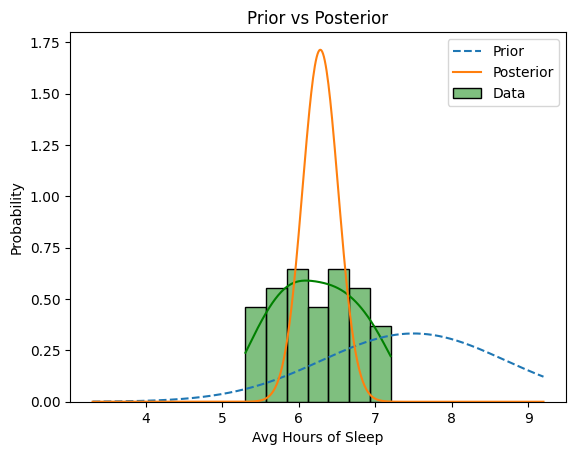

In [62]:
sns.histplot(data['avg_sleep_hours'], kde=True, stat="density", label="Data", color="green")

plt.plot(x, prior_pdf, label="Prior", linestyle="--")
plt.plot(x, posterior_pdf, label="Posterior")

plt.legend()
plt.title("Prior vs Posterior")
plt.xlabel("Avg Hours of Sleep")
plt.ylabel("Probability")
plt.show()

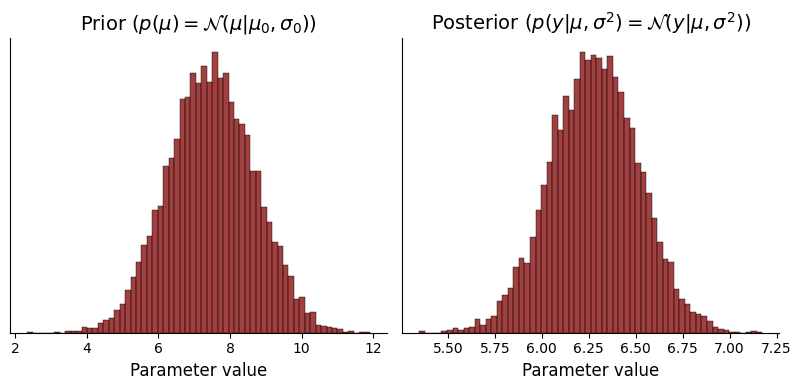

In [55]:
### Visualizing our priors the lazy way
f, axarr = plt.subplots(1, 2, figsize=(8, 4))
param_names = [r'Prior ($p(\mu)=\mathcal{N}(\mu|\mu_0,\sigma_0)$)', r'Posterior ($p(y|\mu,\sigma^2)=\mathcal{N}(y|\mu,\sigma^2)$)',]
sns.histplot(mu_0 + sigma_0 * np.random.standard_normal(size=10000), color='maroon', ax=axarr[0])
sns.histplot(posterior_mu + posterior_sigma * np.random.standard_normal(size=10000), color='maroon', ax=axarr[1])

for ax, p in zip(axarr, param_names):
    ax.set_title(p, fontsize=14)
    ax.set_xlabel('Parameter value', fontsize=12)
    ax.set_yticks([])
    ax.set_ylabel('')
    sns.despine(ax=ax)

f.tight_layout()